### 8. Gated Recurrent Units (GRU)

Основная проблема блока LSTM — большое количество настраиваемых параметров. GRU это упрощение блока LSTM, работающее следующим образом:

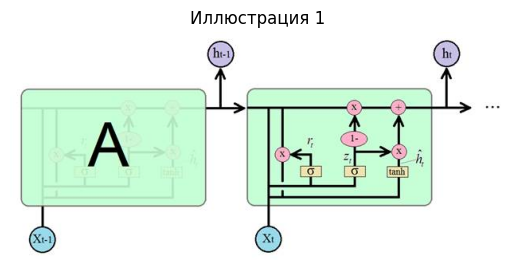

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image = mpimg.imread('illustrations/GRU_0.jpg')

plt.imshow(image)
plt.axis('off')
plt.title('Иллюстрация')
plt.show()

Работа этого блока (ячейки) похожа на блок LSTM, только здесь долгосрочный элемент памяти объединен с вектором скрытого состояния $h_t$. Наверху мы также видим две поэлементные операции умножения и сложения для забывания ненужной информации и запоминания новой:

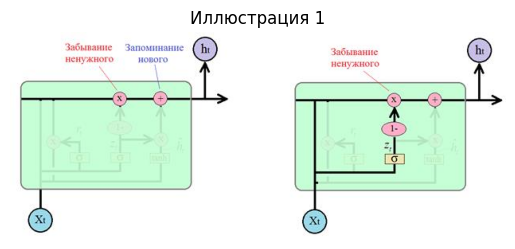

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image1 = mpimg.imread('illustrations/GRU_1.jpg')

plt.imshow(image1)
plt.axis('off')
plt.title('Иллюстрация 1')
plt.show()

Для определения что забыть, а что оставить, используется вектор:

$$
\bar{z}_r = \sigma(W_r \cdot [h_{r-1}, x_r] + b_r)
$$

Который, затем, поэлементно вычитается из 1 и умножается на вектор предыдущего состояния $h_{t-1}$:

$$
\overline{f}_t = \overline{h}_{t-1} \otimes (1 - \overline{z}_t)
$$

Почему здесь вычитание? Чтобы противоположную информацию использовать как маркер для добавления нового в соседней ветке. Если ее полностью расписать, то получится следующая операция:

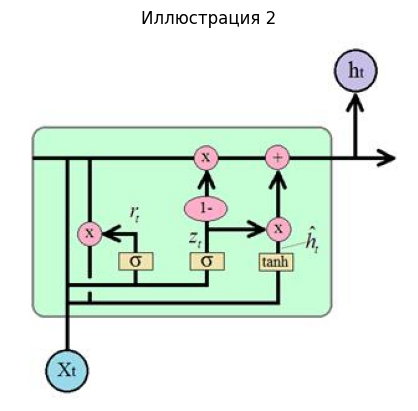

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image2 = mpimg.imread('illustrations/GRU_2.jpg')

plt.imshow(image2)
plt.axis('off')
plt.title('Иллюстрация 2')
plt.show()

$$ r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r) $$

$$ \hat{h}_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot (r_t \otimes h_{t-1}) + b_h) $$

И вычисленная величина добавляется как то, что нужно «запомнить» в векторе скрытого состояния для следующей итерации. В итоге, вычисление $h_{t}$ имеет вид:

$$ h_t = h_{t-1} \otimes (1 - z_t) + \hat{h}_t \otimes z_t $$

### 9. Итог

Эта формула и определяет принцип работы ячейки GRU. Если кто из вас знаком с калмановской фильтрацией случайных сигналов, то полученная формула очень похожа на реализацию фильтра Калмана, только в нелинейном исполнении. В некотором смысле она работает по этому же принципу: отбрасывает случайные (незначительные) детали и сохраняет главное (важное). Одним из общих недостатков блоков LSTM и GRU является их большая склонность к переобучению. Так как каждая ячейка содержит большое число нейронов, то сеть, на их основе также получается большой. А это прямой путь к переобучению.